<a href="https://colab.research.google.com/github/SalvarezJ/Crib-Sentry/blob/main/notebooks/07_measure_after_fix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crib Sentry: Measurement After the Fix
Here I measure the old system and the new system on the same test images and tags. The old system is the Child and Crib detector from notebook 02. The new system is the Crib detector from notebook 05 and the Child detector from notebook 06. The hazard detector and the alert rules are the same in the two systems.

In [ ]:
!pip install -q ultralytics roboflow

from google.colab import drive, userdata
drive.mount('/content/drive')

import glob, os, time, torch
from ultralytics import YOLO
from roboflow import Roboflow

print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NONE')

base = '/content/drive/MyDrive/crib_sentry_v2'
old_child_crib = YOLO(f'{base}/child_crib/weights/best.pt')
new_child = YOLO(f'{base}/child-2/weights/best.pt')
new_crib = YOLO(f'{base}/crib/weights/best.pt')
hazards = YOLO(f'{base}/hazards/weights/best.pt')

rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))
dataset = rf.workspace("test-1caua").project("baby-in-crib").version(1).download("yolov11")
test_images = sorted(glob.glob(dataset.location + '/test/images/*'))
left_images = sorted(glob.glob(f'{base}/left_the_crib_test/*'))
print('Test images:', len(test_images), '| left the crib images:', len(left_images))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.8/336.8 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 137.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 9.9 MB/s eta 0:00:00
Mounted at /content/drive
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
GPU: Tesla T4
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Baby-in-Crib-1 in yolov11:: 100%|██████████| 496/496 [00:00<00:00, 10621.31it/s]


Test images: 24 | left the crib images: 10


## Measure the two systems
The alert rules are the same as in notebook 04. I use my 24 tags from notebook 04 and 10 images with the tag "left the crib".

In [ ]:
assert torch.cuda.is_available() and len(test_images) == 24 and len(left_images) == 10

def fraction_inside(inner, outer):
    x1 = max(inner[0], outer[0]); y1 = max(inner[1], outer[1])
    x2 = min(inner[2], outer[2]); y2 = min(inner[3], outer[3])
    if x2 <= x1 or y2 <= y1:
        return 0.0
    overlap = (x2 - x1) * (y2 - y1)
    inner_area = (inner[2] - inner[0]) * (inner[3] - inner[1])
    return overlap / inner_area

def get_facts(path, child_model, crib_model):
    results = [child_model(path, verbose=False)[0]]
    if crib_model is not child_model:
        results.append(crib_model(path, verbose=False)[0])
    children = []; crib = None; best_conf = 0
    for r in results:
        for box in r.boxes:
            name = r.names[int(box.cls[0])].lower()
            corners = box.xyxy[0].tolist()
            conf = float(box.conf[0])
            if name == 'child':
                children.append(corners)
            elif name == 'crib' and conf > best_conf:
                crib = corners; best_conf = conf
    hazard_list = []
    for box in hazards(path, verbose=False)[0].boxes:
        hazard_list.append((hazards.names[int(box.cls[0])], box.xyxy[0].tolist()))
    return children, crib, hazard_list

def get_alert(path, child_model, crib_model):
    children, crib, hazard_list = get_facts(path, child_model, crib_model)
    if crib is None:
        return 'not visible'
    left_crib = False
    for child in children:
        if fraction_inside(child, crib) <= 0.5:
            left_crib = True
    hazard_present = False
    for name, box in hazard_list:
        if fraction_inside(box, crib) > 0.5:
            hazard_present = True
    if left_crib: return 'left the crib'
    if hazard_present: return 'hazard present'
    if len(children) == 0: return 'not visible'
    return 'all clear'

names = {'c': 'all clear', 'l': 'left the crib', 'n': 'not visible', 'h': 'hazard present'}
tags = [names[x] for x in 'nnnnnccnnhhnnnnnnccnnnnn']
left_tags = ['left the crib'] * 10

def run(images, child_model, crib_model):
    get_alert(images[0], child_model, crib_model)   # the first call loads the model on the GPU
    start = time.time()
    alerts = [get_alert(p, child_model, crib_model) for p in images]
    return alerts, (time.time() - start) / len(images)

for title, images, correct in [('Baby in Crib test images', test_images, tags),
                               ('Left the crib images', left_images, left_tags)]:
    old, old_time = run(images, old_child_crib, old_child_crib)
    new, new_time = run(images, new_child, new_crib)
    print(title)
    print('number | my tag | old system | new system')
    for i in range(len(images)):
        print(i, '|', correct[i], '|', old[i], '' if old[i] == correct[i] else '(WRONG)',
              '|', new[i], '' if new[i] == correct[i] else '(WRONG)')
    for name, alerts, t in [('Old', old, old_time), ('New', new, new_time)]:
        right = sum(a == c for a, c in zip(alerts, correct))
        print(name, 'system:', right, 'of', len(images), '=', round(100 * right / len(images), 1),
              '% |', round(t, 3), 'seconds for each image')
    print()

Baby in Crib test images
number | my tag | old system | new system
0 | not visible | not visible  | not visible 
1 | not visible | not visible  | not visible 
2 | not visible | not visible  | not visible 
3 | not visible | not visible  | not visible 
4 | not visible | all clear (WRONG) | not visible 
5 | all clear | all clear  | all clear 
6 | all clear | all clear  | all clear 
7 | not visible | not visible  | not visible 
8 | not visible | not visible  | not visible 
9 | hazard present | hazard present  | hazard present 
10 | hazard present | hazard present  | hazard present 
11 | not visible | not visible  | not visible 
12 | not visible | not visible  | not visible 
13 | not visible | hazard present (WRONG) | hazard present (WRONG)
14 | not visible | not visible  | all clear (WRONG)
15 | not visible | hazard present (WRONG) | hazard present (WRONG)
16 | not visible | not visible  | not visible 
17 | all clear | not visible (WRONG) | not visible (WRONG)
18 | all clear | all clear  |

## Boxes on the wrong images
Cyan is the crib box, blue is the child box and red is the hazard box.

13 | new system: hazard present
    crib 0.50
    Child 0.78
    hard-toy 0.87
14 | new system: all clear
    crib 0.26
    Child 0.69
15 | new system: hazard present
    crib 0.26
    Child 0.85
    blanket 0.55
17 | new system: not visible
    crib 0.81
19 | new system: hazard present
    crib 0.87
    blanket 0.45
21 | new system: hazard present
    crib 0.90
    blanket 0.64
22 | new system: all clear
    crib 0.91
    Child 0.38


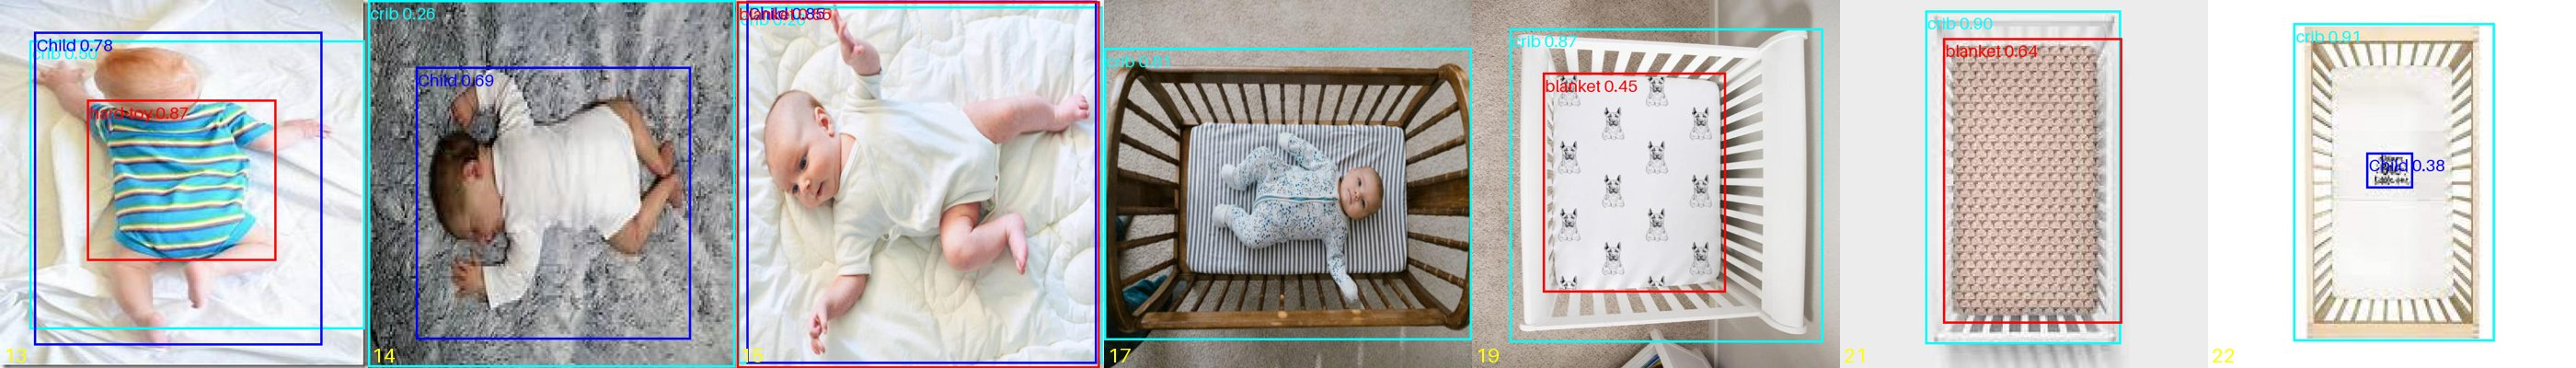

6 | new system: hazard present
    crib 0.73
    Child 0.94
    blanket 0.31
7 | new system: all clear
    crib 0.81
    Child 0.85
9 | new system: hazard present
    crib 0.68
    Child 0.80
    hard-toy 0.53


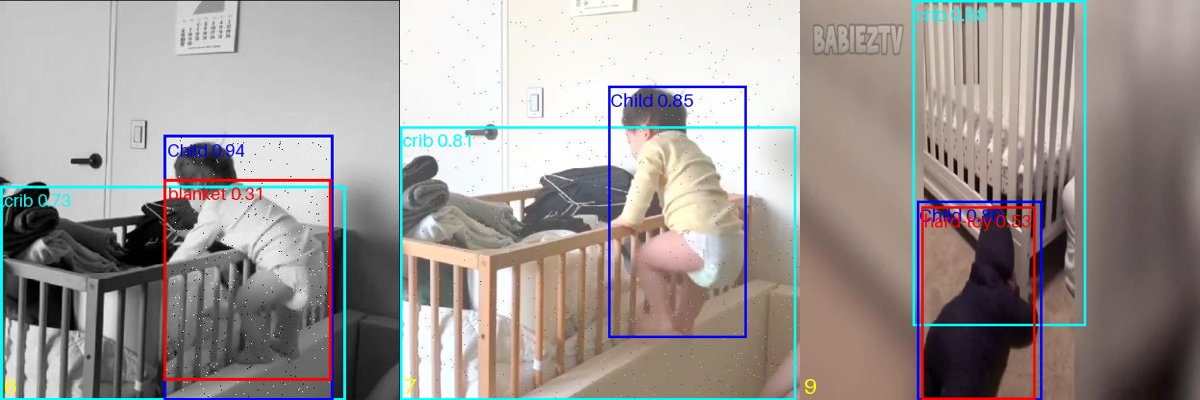

In [ ]:
from PIL import Image as PILImage, ImageDraw, ImageFont
from IPython.display import Image, display

def show(images, numbers, file):
    size = 400
    page = PILImage.new('RGB', (len(numbers) * size, size), 'white')
    for k, n in enumerate(numbers):
        im = PILImage.open(images[n]).convert('RGB')
        w, h = im.size
        d = ImageDraw.Draw(im)
        font = ImageFont.load_default(size=max(14, w // 22))
        print(n, '| new system:', get_alert(images[n], new_child, new_crib))
        for model, color in [(new_crib, 'cyan'), (new_child, 'blue'), (hazards, 'red')]:
            r = model(images[n], verbose=False)[0]
            for box in r.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                text = f'{r.names[int(box.cls[0])]} {float(box.conf[0]):.2f}'
                print('   ', text)
                d.rectangle([x1, y1, x2, y2], outline=color, width=max(3, w // 150))
                d.text((x1 + 4, y1 + 4), text, fill=color, font=font)
        im = im.resize((size, size))
        ImageDraw.Draw(im).text((4, size - 28), str(n), fill='yellow', font=ImageFont.load_default(size=22))
        page.paste(im, (k * size, 0))
    page.save(file, quality=85)
    display(Image(filename=file))

show(test_images, [13, 14, 15, 17, 19, 21, 22], '/content/wrong_test.jpg')
show(left_images, [6, 7, 9], '/content/wrong_left.jpg')

## Results after the fix
I measure the old system and the new system on the same test images.

- On the 24 test images, the old system gets 18 correct (75.0%) and the new system gets 17 correct (70.8%). My target was 85%.
- On the 10 "left the crib" images, the old system gets 0 correct and the new system gets 7 correct.
- The new system uses 0.034 seconds for each image on the T4 GPU. My target was less than 1 second.

The new system still makes these errors:
- The Crib detector puts a weak crib box on three photos that show a baby with no crib.
- The Child detector does not find one baby, and it puts a child box on printed words one time.
- The hazard detector reads two fitted sheets as blankets.
- In a side view, the box of a child that climbs out is still on the crib box. Thus my "inside" rule fails three times.